# Tinkering with the FHWA framework model


## Step 1 - obtain data
We're going to use a locally stored version of the FHWA library

NOTE: I have stored my environment variables in my jupyter kernel file (see https://stackoverflow.com/a/53595397) so that I don't have to enter them every time.

In [1]:
import os
os.getenv('BLACKBOOK_USERNAME')


'scope3'

In [4]:
BB_HOST = 'https://sc.vault.lc'

### LCIA

In [3]:
from antelope_foreground import ForegroundCatalog
cat = ForegroundCatalog()

cat.blackbook_authenticate(BB_HOST)
cat.get_blackbook_resources('lcia.openlca.2.7.5')

t1 = next(cat.query('lcia.openlca.2.7.5').lcia(method='TRACI 2.1'))
t2 = next(cat.query('lcia.openlca.2.7.5').lcia(method='TRACI 2.2'))

Loading JSON data from /data/GitHub/Antelope/core/antelope_core/archives/data/elcd_reference_quantities.json:
local.qdb: /data/GitHub/Antelope/core/antelope_core/archives/data/elcd_reference_quantities.json
local.qdb: Setting NSUUID (False) 77833297-6780-49bf-a61a-0cb707dce700
local.qdb: /data/GitHub/lca-tools/lcatools/qdb/data/elcd_reference_quantities.json
29 total quantity entities added (29 new)
6 total flow entities added (6 new)
POST https://sc.vault.lc/auth/token.. 200 [0.62 sec]
Welcome back to blackbook, hosted by ANTELOPE_AUTHORITY.
Username: scope3, email: modeler@scope3consulting.com
Last login: Tue Sep  9 09:43:16 2025 
token expires in 36000 s
GET https://sc.vault.lc/origins/lcia.openlca.2.7.5/resource.. 200 [0.13 sec]
QQQQQQQQQQQQQQQQQQ lcia.openlca.2.7.5 QQQQQQQQQQQQQQQQQQ
Found Antelope providers:
AntelopeMeta:_dev
antelope_core.providers:IlcdArchive
antelope_core.providers:IlcdLcia
antelope_core.providers:EcospoldV2Archive
antelope_core.providers:EcospoldV1Archive
ant

### FHWA

If you provide a catalog root to ForegroundCatalog(), this 30 seconds of startup would only need to be done once.

In [4]:
if 'fhwa' not in cat.origins:
    FHWA = '/data/LCI/FedCommons/Federal_Highway_Administration-mtu_pavement.zip'

    # set static=True to load the entire dataset
    cat.new_resource('fhwa', FHWA, 'OpenLcaJsonLdArchive', interfaces=('basic', 'exchange', 'quantity'))
    cat.index_ref('fhwa')
    cat.background_for_origin('fhwa')  # takes about 30 seconds to load the archive

    # set multi_term='cutoff' to cut-off ambiguous flows
    cat.query('fhwa').check_bg(multi_term='cutoff')  # takes about 10 seconds to create the ordered background


QQQQQQQQQQQQQQQQQQ fhwa QQQQQQQQQQQQQQQQQQ
fhwa: /data/LCI/FedCommons/Federal_Highway_Administration-mtu_pavement.zip
fhwa: Setting NSUUID (False) None
Found Extension: zip
Loading /data/LCI/FedCommons/Federal_Highway_Administration-mtu_pavement.zip
fhwa.index.20250909: None
fhwa.index.20250909: Setting NSUUID (None) f032f768-fc5b-461b-86e9-3e58d2710edb
Ignoring ns_uuid specification
fhwa: /data/LCI/FedCommons/Federal_Highway_Administration-mtu_pavement.zip
289 total quantity entities added (289 new)
5215 total flow entities added (5215 new)
1298 total process entities added (1298 new)
QQQQQQQQQQQQQQQQQQ fhwa.index.20250909 QQQQQQQQQQQQQQQQQQ
fhwa.index.20250909: fhwa.index.20250909_background.mat
fhwa.index.20250909: Setting NSUUID (False) None
Creating flat background
c245a252-0860-41d2-9789-802bab7984ab: Disposal, wastewater treatment plant residuals, to uns. beneficial use [Input]: Target 4cb0c558-b0ac-3656-bc1f-95b477c14921 MISSING REFERENCE
c245a252-0860-41d2-9789-802bab7984ab: U

## Step 2 - Inspect our model

In [5]:
fg = cat.foreground('work', create=True)

QQQQQQQQQQQQQQQQQQ work QQQQQQQQQQQQQQQQQQ
work: work
work: Setting NSUUID (None) None
Loading work
0 total fragment entities added (0 new)


In [6]:
p = next(cat.query('fhwa').processes(name='asphalt mixture - framework'))

In [7]:
model = fg.create_process_model(p)
fg.extend_process(model)

In [8]:
model.show_tree()

   -<--O   9ac07 [     907 kg] Asphalt Mix
    [   1 unit] Asphalt Mix
       |        Stage: Asphalt mixture - Framework 
       | -<--*   e5a3f (=      1 kg) Asphalt Mix
       |  [   1 kg] Asphalt Mix
       |     |        Stage: Asphalt binder, no additives, consumption mix, at terminal, from crude oil
       |     | -<--B*  b5c92 [   0.035 kg] Asphalt binder, no additives
       |     |        Stage: Electricity; at grid; consumption mix - US - US
       |     | -<--B*  11cc1 [   0.011 MJ] Electricity, AC, 2300-7650 V
       |     |        Stage: Natural gas, combusted in industrial boiler
       |     | -<--B*  caf60 [ 0.00583 m3] Natural gas, combusted in industrial boiler
       |     |        Stage: Production of Aggregate
       |     | -<--B*  0a540 [   0.675 kg] Aggregate
       |     |        Stage: RAP
       |     | -<--B*  de53f [   0.275 kg] RAP
       |     |        Stage: Transport, combination truck, diesel powered
       |     | -<--B*  e2fc8 [   0.127 t*km] Transp

In [10]:
fg.extend_process(model, inventory=True)

No child flow found; creating new [fhwa] RAS  [kg] Input
No child flow found; creating new [fhwa] Soy biodiesel, production, at plant [kg] Input
No child flow found; creating new [fhwa] Diesel, combusted in industrial equipment [m3] Input
No child flow found; creating new [fhwa] Asphalt binder [kg] Input
No child flow found; creating new [fhwa] Asphalt binder [kg] Input
No child flow found; creating new [fhwa] Asphalt binder [kg] Input
No child flow found; creating new [fhwa] Recycled Fuel Oil - CA [m3] Input
No child flow found; creating new [fhwa] Residual fuel oil, combusted in industrial boiler [m3] Input
No child flow found; creating new [fhwa] Liquefied petroleum gas, combusted in industrial boiler [m3] Input


In [11]:
model.show_tree()

   -<--O   9ac07 [     907 kg] Asphalt Mix
    [   1 unit] Asphalt Mix
       |        Stage: Asphalt mixture - Framework 
       | -<--*   e5a3f (=      1 kg) Asphalt Mix
       |  [   1 kg] Asphalt Mix
       |     |        Stage: Asphalt binder, 0.5% polyphosphoric acid (PPA), consumption mix, at terminal, from crude oil, 0.5% polyphosphoric acid
       |     | -<--B*  a87e0 (       0 kg) Asphalt binder
       |     |        Stage: Asphalt binder, 3.5% styrene-butadiene-styrene (SBS), consumption mix, at terminal, from crude oil, 3.5% styrene-butadiene-styrene
       |     | -<--B*  d5083 (       0 kg) Asphalt binder
       |     |        Stage: Asphalt binder, 8% ground rubber tire (GRT), consumption mix, at terminal, from crude oil, 8% ground rubber tire
       |     | -<--B*  3a5d1 (       0 kg) Asphalt binder
       |     |        Stage: Asphalt binder, no additives, consumption mix, at terminal, from crude oil
       |     | -<--B*  b5c92 [   0.035 kg] Asphalt binder, no additi

#### Take a look at the results

In [12]:
from antelope import enum

In [13]:
p.show()

ProcessRef catalog reference (c86d1b3b-731b-4880-82ad-976b3796c502)
origin: fhwa
   UUID: c86d1b3b-731b-4880-82ad-976b3796c502
   Name: Asphalt mixture - Framework 
Comment: 
Exchange ID 21 (d815ff18-015c-3afb-be18-be03bdf325da): Unit Conversion Error from 0.00016 m3*a to m3
Exchange ID 18 (e04995fa-935b-316c-b112-5b436c8ea3d6): Unit Conversion Error from 0 m3*a to m3
reference: [ Asphalt mixture - Framework  [US] ]*==>  907 (kg) Asphalt Mix 
==Local Fields==
        Classifications: ['Asphalt Mixture_Parameterized', 'Fundamental Construct for Asphalt Mixture']
           SpatialScope: US
          TemporalScope: {}
                  @type: Process
            description: This asphalt mixture process is the base case for the asphalt mixtures LCA.

This is a parameterized inventory. 
When using this please note:
- the paramter Total_amount_of_binder indicates the target amount = virgin binder + binder derived from RAP/RAS
- to define a mix, %RAP or %RAS and target asphalt binder %
- fu

In [14]:
lcias = enum(cat.query('fhwa').lcia())

 [00] [fhwa] TRACI 2.1 (NETL mod) [0]
 [01] [fhwa] CED for FEDEFL-adapted LCI [0]
 [02] [lcia.openlca.2.7.5] TRACI 2.1 [0]


In [15]:
traci_netl = lcias[0]
traci_dflt = lcias[2]

In [17]:
q = cat.query('fhwa')

In [18]:
ts = [q.get(k) for k in traci_netl['ImpactCategories']]

In [20]:
os = [cat.query(traci_dflt.origin).get(k) for k in traci_dflt['ImpactCategories']]

GET https://xdb.localhost/lcia.openlca.2.7.5/0e45786f-67fa-3b8a-b8a3-73a7c316434c.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/e0916d62-7fbd-3d0a-a4a5-52659b0ac9c1.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/31967441-d687-313d-9910-13da3a584ab7.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/a6e5e5d8-a1e5-3c77-8170-586c4fe37514.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/7a149078-e2fd-3e07-a5a3-79035c60e7c3.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/75d0c8a2-e466-3bd7-813b-5beef2209330.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/d4827ae3-c873-3ea4-85fb-860b7f3f2dee.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/6c05dad1-6661-35f2-82aa-6e8e6a498aec.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/45b8cd56-498a-3c6f-9488-134e951d8c02.. 200 [0.00 sec]
GET https://xdb.localhost/lcia.openlca.2.7.5/338e9370-ceb0-3d18-9d87-5f91feb7829c.. 200 [0.00 sec]


In [21]:
model.fragment_lcia(ts[2]).show_components()

exact result
completed 0 iterations
Imported 40 factors for [fhwa] TRACI 2.1 (NETL mod), Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
exact result
completed 0 iterations
completed 25 iterations
exact result
completed 0 iterations
completed 25 iterations
completed 25 iterations
completed 26 iterations
[fhwa] TRACI 2.1 (NETL mod), Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)] kg CO2 eq
------------------------------------------------------------
S      20.9 =       31.8 x      0.658 | b5c92        31.8 [ Input] -B*  Asphalt binder, no additives, consumption mix, at terminal, from crude oil [Northern America]
S      12.9 =       5.29 x       2.44 | caf60        5.29 [ Input] -B*  Natural gas, combusted in industrial boiler [Northern America]
S      11.3 =        115 x     0.0978 | e2fc8         115 [ Input] -B*  Transport, combination truck, diesel powered [Northern America]
S      1.56 =         10 x      0.156 | 11cc1          10 [ Input] -B*

### Adjust exchange values

In [29]:
p.show()

ProcessRef catalog reference (c86d1b3b-731b-4880-82ad-976b3796c502)
origin: fhwa
   UUID: c86d1b3b-731b-4880-82ad-976b3796c502
   Name: Asphalt mixture - Framework 
Comment: 
Exchange ID 21 (d815ff18-015c-3afb-be18-be03bdf325da): Conversion Error from unit m3*a to m3
Exchange ID 18 (e04995fa-935b-316c-b112-5b436c8ea3d6): Conversion Error from unit m3*a to m3
reference: [ Asphalt mixture - Framework  [US] ]*==>  907 (kg) Asphalt Mix 
==Local Fields==
        Classifications: ['Asphalt Mixture_Parameterized', 'Fundamental Construct for Asphalt Mixture']
           SpatialScope: US
          TemporalScope: {}
                  @type: Process
            description: This asphalt mixture process is the base case for the asphalt mixtures LCA.

This is a parameterized inventory. 
When using this please note:
- the paramter Total_amount_of_binder indicates the target amount = virgin binder + binder derived from RAP/RAS
- to define a mix, %RAP or %RAS and target asphalt binder %
- fuels for pr

In [30]:
olca2 = cat.get_archive(p.origin)

In [34]:
j, _, _ = olca2._clean_object('processes', p.uuid)

In [38]:
next(k for k in j['exchanges'] if k['internalId'] == 21)

{'@type': 'Exchange',
 'amount': 0.00016,
 'amountFormula': 'combustion_of_Diesel_Industrial_Equipment ',
 'internalId': 21,
 'defaultProvider': {'@type': 'Process',
  '@id': 'd6ad7035-5498-3237-8abd-50e93b1eef89',
  'name': 'Diesel, combusted in industrial equipment',
  'processType': 'UNIT_PROCESS',
  'location': 'RNA',
  'category': '22: Utilities/2213: Water, Sewage and Other Systems',
  'flowType': 'PRODUCT_FLOW'},
 'flow': {'@type': 'Flow',
  '@id': 'd815ff18-015c-3afb-be18-be03bdf325da',
  'name': 'Diesel, combusted in industrial equipment',
  'flowType': 'PRODUCT_FLOW',
  'location': 'RNA',
  'refUnit': 'm3',
  'category': 'Technosphere Flows/22: Utilities/2213: Water, Sewage and Other Systems'},
 'unit': {'@type': 'Unit',
  '@id': 'ee5f2241-18af-4444-b457-b275660e5a20',
  'name': 'm3*a'},
 'flowProperty': {'@type': 'FlowProperty',
  '@id': '93a60a56-a3c8-22da-a746-0800200c9a66',
  'name': 'Volume',
  'category': 'Technical flow properties'},
 'isAvoidedProduct': False,
 'isInp

`children_with_flow` should be recursive, so we could omit the `balance_flow` specification - it should just crawl the whole tree and generate matching child flows. It should also match on `external_ref`, not just flow entity.

In [22]:
next(model.balance_flow.children_with_flow(q.get('d815ff18-015c-3afb-be18-be03bdf325da'))).show()

(e5a3f2e) -<- dd356 -<- -B*   [   1 m3] Diesel, combusted in industrial equipment 
LcFragment Entity (ref dd3563db-b422-4fb3-b44a-0e832c1a2524)
origin: work
reference: (9ac07b4) -<- e5a3f -<- -*    [   1 kg] Asphalt Mix 
     Name: Diesel, combusted in industrial equipment
  Comment: combustion_of_Diesel_Industrial_Equipment
StageName: Diesel, combusted in industrial equipment
Exchange values: 
              Cached: 0
            Observed: 0

Balance flow: False
Terminations: 
            Scenario  Termination
                None: -B*  (agg) [fhwa] Diesel, combusted in industrial equipment [Northern America]


We correct the model by observing the correct exchange value.

Note that we divide by the reference flow, because the exchange value given in the dataset is per 907 kg, but 

In [98]:
fg.observe(next(model.balance_flow.children_with_flow(q.get('d815ff18-015c-3afb-be18-be03bdf325da'))), exchange_value=0.00016 / model.observed_ev)

'fhwa.fg/8917a4e5-89d7-4b88-80a7-510f4aff769d'

In [99]:
model.fragment_lcia(tt[2]).show_components()

[lcia.openlca.2.7.5] TRACI 2.1, Global warming [kg CO2 eq] [TRACI 2.1] kg CO2 eq
------------------------------------------------------------
S      20.1 =       31.8 x      0.632 | b4913        31.8 [ Input] -B*  Asphalt binder, no additives, consumption mix, at terminal, from crude oil [Northern America]
S      12.5 =       5.29 x       2.36 | 9f2ff        5.29 [ Input] -B*  Natural gas, combusted in industrial boiler [Northern America]
S      11.1 =        115 x     0.0961 | 8ca24         115 [ Input] -B*  Transport, combination truck, diesel powered [Northern America]
S      1.53 =         10 x      0.153 | 411fc          10 [ Input] -B*  Electricity; at grid; consumption mix - US - US [US]
S     0.833 =        612 x    0.00136 | ab8f0         612 [ Input] -B*  Production of Aggregate [GLO]
S     0.528 =    0.00016 x    3.3e+03 | 8917a     0.00016 [ Input] -B*  Diesel, combusted in industrial equipment [Northern America]
S     0.143 =       6.28 x     0.0228 | 93f61        6.28 [ I

What about the other broken exchange?

In [49]:
next(k for k in j['exchanges'] if k['internalId'] == 18)

{'@type': 'Exchange',
 'amount': 0.0,
 'amountFormula': 'combustion_of_Diesel_Industrial_Boiler ',
 'internalId': 18,
 'defaultProvider': {'@type': 'Process',
  '@id': '53804132-4bd6-3b18-bfbd-14ac762431ef',
  'name': 'Diesel, combusted in industrial boiler',
  'processType': 'UNIT_PROCESS',
  'location': 'RNA',
  'category': '22: Utilities/2213: Water, Sewage and Other Systems',
  'flowType': 'PRODUCT_FLOW'},
 'flow': {'@type': 'Flow',
  '@id': 'e04995fa-935b-316c-b112-5b436c8ea3d6',
  'name': 'Diesel, combusted in industrial boiler',
  'flowType': 'PRODUCT_FLOW',
  'location': 'RNA',
  'refUnit': 'm3',
  'category': 'Technosphere Flows/22: Utilities/2213: Water, Sewage and Other Systems'},
 'unit': {'@type': 'Unit',
  '@id': 'ee5f2241-18af-4444-b457-b275660e5a20',
  'name': 'm3*a'},
 'flowProperty': {'@type': 'FlowProperty',
  '@id': '93a60a56-a3c8-22da-a746-0800200c9a66',
  'name': 'Volume',
  'category': 'Technical flow properties'},
 'isAvoidedProduct': False,
 'isInput': True}

It's already zero.


### What about the choice of asphalt binder?
What are our choices?

In [23]:
import pandas as pd

In [24]:
binders = pd.DataFrame(({'Name': f.term.term_node.name, 'Fragment': f.external_ref, 'Target': f.term.term_node.external_ref} 
                        for f in model.balance_flow.child_flows
                        if f.name.lower().find('binder') >= 0))

In [25]:
binders

,Name,Fragment,Target
0,"Asphalt binder, no additives, consumption mix,...",b5c927d9-a723-4456-9c26-8084e5bfe56d,f8ce5199-1666-452b-a267-8797c94d0560
1,"Asphalt binder, 0.5% polyphosphoric acid (PPA)...",a87e098a-fe13-4781-bde8-b78390e9213c,28d7d56e-a751-492c-9bb1-08f19ea4ac37
2,"Asphalt binder, 3.5% styrene-butadiene-styrene...",d508371f-a637-4707-b2ef-003155a4aa0f,bbf3dc45-a370-405e-8996-7358b7f1841c
3,"Asphalt binder, 8% ground rubber tire (GRT), c...",3a5d1ee8-4f1f-497a-ba96-8980f63d4a74,72d5a381-8cae-4e1d-b0a3-26cc43b69867


In [26]:
binders['scenario'] = ['Default', 'PPA', 'SBR', 'GRT']
binders = binders.set_index('scenario')
binders

,Name,Fragment,Target
scenario,,,
Default,"Asphalt binder, no additives, consumption mix,...",b5c927d9-a723-4456-9c26-8084e5bfe56d,f8ce5199-1666-452b-a267-8797c94d0560
PPA,"Asphalt binder, 0.5% polyphosphoric acid (PPA)...",a87e098a-fe13-4781-bde8-b78390e9213c,28d7d56e-a751-492c-9bb1-08f19ea4ac37
SBR,"Asphalt binder, 3.5% styrene-butadiene-styrene...",d508371f-a637-4707-b2ef-003155a4aa0f,bbf3dc45-a370-405e-8996-7358b7f1841c
GRT,"Asphalt binder, 8% ground rubber tire (GRT), c...",3a5d1ee8-4f1f-497a-ba96-8980f63d4a74,72d5a381-8cae-4e1d-b0a3-26cc43b69867


#### Take 1 - pick each one at a time

In [27]:
for scenario in binders.index:
    for entr, row in binders.iterrows():
        if entr == scenario:
            _obs = 0.035
        else:
            _obs = 0
        fg.observe(fg.get(row['Fragment']), exchange_value=_obs, scenario=scenario)

In [28]:
from antelope_reports.model_runner import ScenarioRunner

In [ ]:
model.show_tree('GRT')

In [103]:
qs = enum(q.lcia())

 [00] [fhwa] TRACI 2.1 (NETL mod) [0]
 [01] [fhwa] CED for FEDEFL-adapted LCI [0]
 [02] [lcia.openlca.2.7.5] TRACI 2.1 [0]


In [32]:
sc = ScenarioRunner(model)
for scenario in binders.index:
    sc.add_case(scenario, scenario)  # first arg is case name, second arg is scenario specifciation
for t in ts:
    sc.run_lcia(t)
sc.to_dataframe()

traversing Default
traversing PPA
traversing SBR
traversing GRT
exact result
completed 0 iterations
Imported 159 factors for [fhwa] TRACI 2.1 (NETL mod), Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
exact result
completed 0 iterations
exact result
completed 0 iterations
exact result
completed 0 iterations
Imported 13 factors for [fhwa] TRACI 2.1 (NETL mod), Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
Imported 606 factors for [fhwa] TRACI 2.1 (NETL mod), Human health - non-cancer [CTUnoncancer] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
Imported 22 factors for [fhwa] TRACI 2.1 (NETL mod), Eutrophication [kg N eq] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
Imported 1077 factors for [fhwa] TRACI 2.1 (NETL mod), Freshwater ecotoxicity [CTUeco] [TRACI 2.1 (NETL mod)]
exact result
completed 0 iterations
Imported 22 factors for [fhwa] TRACI 2.1 (NETL mod), Ozone depletion [kg CFC-1

,Default,PPA,SBR,GRT
"[fhwa] TRACI 2.1 (NETL mod), Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)]",4.016639e+00,4.034326e+00,4.230329e+00,3.975287e+00
"[fhwa] TRACI 2.1 (NETL mod), Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)]",1.470402e-01,1.525640e-01,1.576671e-01,1.442160e-01
"[fhwa] TRACI 2.1 (NETL mod), Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)]",4.764866e+01,4.822108e+01,5.183832e+01,4.712073e+01
"[fhwa] TRACI 2.1 (NETL mod), Human health - non-cancer [CTUnoncancer] [TRACI 2.1 (NETL mod)]",4.001105e-05,4.004543e-05,4.094631e-05,3.966710e-05
"[fhwa] TRACI 2.1 (NETL mod), Eutrophication [kg N eq] [TRACI 2.1 (NETL mod)]",1.062569e-02,1.072932e-02,1.327284e-02,1.032512e-02
"[fhwa] TRACI 2.1 (NETL mod), Freshwater ecotoxicity [CTUeco] [TRACI 2.1 (NETL mod)]",1.055147e+02,1.055936e+02,1.059133e+02,1.045773e+02
"[fhwa] TRACI 2.1 (NETL mod), Ozone depletion [kg CFC-11 eq] [TRACI 2.1 (NETL mod)]",9.906074e-08,9.910465e-08,9.921641e-08,9.901018e-08
"[fhwa] TRACI 2.1 (NETL mod), Human health - cancer [CTUcancer] [TRACI 2.1 (NETL mod)]",2.515353e-07,2.520431e-07,2.590508e-07,2.469512e-07
"[fhwa] TRACI 2.1 (NETL mod), Human health - particulate matter [PM 2.5 eq] [TRACI 2.1 (NETL mod)]",6.893248e-03,7.336898e-03,7.440121e-03,6.724572e-03


### Waterfall Chart

In [34]:
from antelope_reports.charts import WaterfallChart

In [38]:
for l in sc.quantities:
    l['Name'] = l['Category']

Creating 1x9 Layout
Creating figure with size 16.00 x 5.83
Case: Default Quantity: [fhwa] Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)] 
Case: PPA Quantity: [fhwa] Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)] 
Case: SBR Quantity: [fhwa] Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)] 
Case: GRT Quantity: [fhwa] Smog formation [kg O3 eq] [TRACI 2.1 (NETL mod)] 
Case: Default Quantity: [fhwa] Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)] 
Case: PPA Quantity: [fhwa] Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)] 
Case: SBR Quantity: [fhwa] Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)] 
Case: GRT Quantity: [fhwa] Acidification [kg SO2 eq] [TRACI 2.1 (NETL mod)] 
Case: Default Quantity: [fhwa] Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)] 
Case: PPA Quantity: [fhwa] Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)] 
Case: SBR Quantity: [fhwa] Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)] 
Case: GRT Quantity: [fhwa] Global warming [kg CO2 eq] [TRACI 2.1 (NETL mod)] 
C

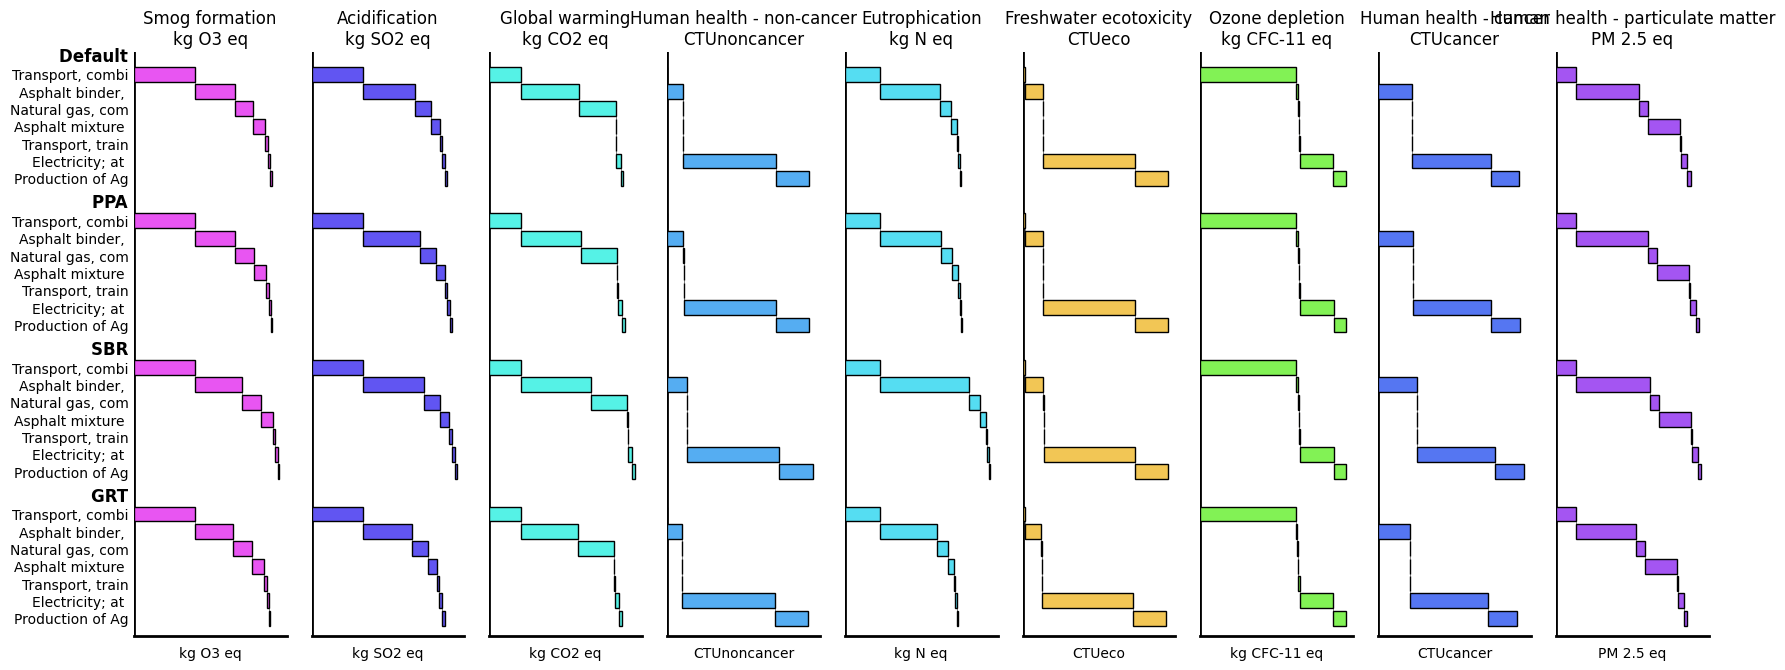

In [40]:
WaterfallChart(*(sc.result(k, l).aggregate(key=lambda x: x.name[:16]) for k in sc.scenarios for l in sc.quantities), 
               size=16,
               data_free=True, filename='none')

### Compare LCIA methods

In [115]:
pd.DataFrame({k['method']: p.bg_lcia(k).details_as_series for k in q.lcia_methods(name='global w')})

Imported 83 factors for [fhwa] TRACI 2.1, Global warming [kg CO2 eq] [TRACI 2.1]


,,,TRACI 2.1 (NETL mod),TRACI 2.1
HCFC-141b,Output,to air,2.004699e-11,NaN
HCFC-225cb,Output,to air,1.012902e-13,NaN
Halon 1211,Output,to air,6.230728e-12,NaN
CFC-13,Output,to air,1.090373e-06,NaN
Hexafluoroethane,Output,to air,3.447508e-08,3.408395e-08
...,...,...,...,...
Dinitrogen monoxide,Output,to air,NaN,2.457079e-04
Dichlorofluoromethane,Output,to air,NaN,9.112800e-14
"1,1,1-Trifluoroethane",Output,to air,NaN,3.924990e-08
"1-Chloro-1,1-difluoroethane",Output,to air,NaN,6.885426e-10


#### play around with flow terminations and anchors